# 26. ResNet-18 full CIFAR-10 PTQ and codebook sweep (2--8 bits)

This notebook performs a full-model weight-only sweep for both custom methods:

- symmetric per-output-channel PTQ;
- tensor-local scalar codebook quantization with $K=2^b$; and
- bit widths $b=2,3,\ldots,8$.

All 21 eligible floating rank-$\geq2$ tensors (20 convolution kernels and the final dense kernel) are quantized. Rank-one biases and normalization parameters stay FP32. Every configuration starts independently from the same trained FP32 checkpoint and is evaluated on all 10,000 CIFAR-10 test images. Quantized weights are reconstructed for FP32 Keras inference; activations remain FP32, and no fake quantization or retraining is used.

The notebook is resumable. Existing PTQ W2--W8 and verified codebook W4/W8 results are seeded from saved artifacts. Only missing configurations are executed, and the result CSV is saved after every completed run.


In [1]:
from pathlib import Path
import gc
import json
import sys
import time

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'src').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.quantization.custom_quantization import (
    codebook_vectorize_model_n_bits, custom_ptq_n_bits, dequantize_tensor,
    reconstruct_codebook_model_weights,
)

MODEL_PATH = PROJECT_ROOT / 'artifacts' / 'resnet18_cifar10_training' / 'resnet18_cifar10_fp32.keras'
PTQ_SEED_PATH = PROJECT_ROOT / 'artifacts' / 'resnet18_custom_ptq_bit_sweep' / 'custom_ptq_2_to_8_bit_accuracy.csv'
W4_W8_SEED_PATH = PROJECT_ROOT / 'artifacts' / 'resnet18_4bit_layer_sensitivity' / 'full_model_w4_vs_w8.csv'
OUTPUT_DIR = PROJECT_ROOT / 'artifacts' / 'resnet18_full_ptq_codebook_bit_sweep'
RESULT_PATH = OUTPUT_DIR / 'resnet18_ptq_codebook_2_to_8_bit.csv'
FIGURE_PATH = OUTPUT_DIR / 'resnet18_ptq_codebook_2_to_8_bit.png'
PREDICTION_CACHE_DIR = OUTPUT_DIR / 'prediction_cache'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_CACHE_DIR.mkdir(parents=True, exist_ok=True)

BITS = tuple(range(2, 9))
METHODS = ('ptq', 'codebook')
NUM_TEST_IMAGES = 10_000
BATCH_SIZE = 32
RANDOM_SEED = 42
CODEBOOK_MAX_SAMPLES = 100_000
CODEBOOK_ITERATIONS = 30
REUSE_SAVED_RESULTS = True
FORCE_RECOMPUTE = False

if not MODEL_PATH.exists():
    raise FileNotFoundError(f'Missing trained model: {MODEL_PATH}. Run notebook 06 first.')
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'Model: {MODEL_PATH}')
print(f'Results: {RESULT_PATH}')


/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_cifar10_training/resnet18_cifar10_fp32.keras
Results: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_full_ptq_codebook_bit_sweep/resnet18_ptq_codebook_2_to_8_bit.csv


## 1. Load the FP32 model and complete CIFAR-10 test split


In [2]:
model = keras.models.load_model(MODEL_PATH, compile=False)
baseline_weights = [weight.numpy() for weight in model.weights]
weight_names = [getattr(weight, 'path', weight.name) for weight in model.weights]
weight_index_by_name = {name: index for index, name in enumerate(weight_names)}

candidate_names = {
    name for name, values in zip(weight_names, baseline_weights)
    if np.issubdtype(values.dtype, np.floating) and values.ndim >= 2
}
assert len(candidate_names) == 21, f'Expected 21 eligible tensors, found {len(candidate_names)}'

(_, _), (test_images, test_labels) = keras.datasets.cifar10.load_data()
test_labels = test_labels.reshape(-1).astype(np.int32)
assert len(test_images) == len(test_labels) == NUM_TEST_IMAGES

image_converter = keras_hub.layers.ResNetImageConverter(
    image_size=(224, 224),
    scale=[0.017124753831663668, 0.01750700280112045, 0.017429193899782133],
    offset=[-2.1179039301310043, -2.0357142857142856, -1.8044444444444445],
    interpolation='bicubic', crop_to_aspect_ratio=True,
)
fp32_parameter_bytes = int(sum(values.nbytes for values in baseline_weights))
candidate_table = pd.DataFrame([
    {
        'tensor': name, 'weight_index': weight_index_by_name[name],
        'shape': baseline_weights[weight_index_by_name[name]].shape,
        'rank': baseline_weights[weight_index_by_name[name]].ndim,
        'parameter_count': baseline_weights[weight_index_by_name[name]].size,
    }
    for name in weight_names if name in candidate_names
])
display(candidate_table)
print(f'FP32 parameter size: {fp32_parameter_bytes / 1024**2:.2f} MiB')


,tensor,weight_index,shape,rank,parameter_count
0,conv1_conv/kernel,0,"(7, 7, 3, 64)",4,9408
1,stack0_block0_1_conv/kernel,5,"(3, 3, 64, 64)",4,36864
2,stack0_block0_2_conv/kernel,10,"(3, 3, 64, 64)",4,36864
3,stack0_block1_1_conv/kernel,15,"(3, 3, 64, 64)",4,36864
4,stack0_block1_2_conv/kernel,20,"(3, 3, 64, 64)",4,36864
5,stack1_block0_1_conv/kernel,25,"(3, 3, 64, 128)",4,73728
6,stack1_block0_0_conv/kernel,30,"(1, 1, 64, 128)",4,8192
7,stack1_block0_2_conv/kernel,31,"(3, 3, 128, 128)",4,147456
8,stack1_block1_1_conv/kernel,40,"(3, 3, 128, 128)",4,147456
9,stack1_block1_2_conv/kernel,45,"(3, 3, 128, 128)",4,147456


FP32 parameter size: 42.69 MiB


## 2. Prediction, reconstruction, and storage helpers


In [3]:
def predict_labels(eval_model):
    batches = []
    for start in range(0, NUM_TEST_IMAGES, BATCH_SIZE):
        batch = image_converter(test_images[start:start + BATCH_SIZE])
        logits = eval_model(batch, training=False).numpy()
        batches.append(np.argmax(logits, axis=1))
    return np.concatenate(batches).astype(np.int16)

def evaluate_reconstructed_weights(tag, weights):
    cache_path = PREDICTION_CACHE_DIR / f'{tag}.npy'
    if cache_path.exists() and not FORCE_RECOMPUTE:
        predictions = np.load(cache_path)
        if len(predictions) != NUM_TEST_IMAGES:
            raise ValueError(f'Stale prediction cache: {cache_path}')
        return predictions, True
    eval_model = keras.models.load_model(MODEL_PATH, compile=False)
    eval_model.set_weights(weights)
    predictions = predict_labels(eval_model)
    np.save(cache_path, predictions)
    del eval_model
    gc.collect()
    return predictions, False

def reconstruct_ptq_weights(weight_result):
    replacements = {tensor.name: dequantize_tensor(tensor) for tensor in weight_result.tensors}
    if set(replacements) != candidate_names:
        raise RuntimeError('PTQ reconstruction coverage does not match the 21-tensor policy.')
    weights = [values.copy() for values in baseline_weights]
    for name, values in replacements.items():
        index = weight_index_by_name[name]
        weights[index] = values.astype(weights[index].dtype)
    return weights

def ptq_representation_bytes(weight_result, bits):
    size = fp32_parameter_bytes
    for tensor in weight_result.tensors:
        original = baseline_weights[weight_index_by_name[tensor.name]]
        packed_values = (original.size * bits + 7) // 8
        size -= original.nbytes
        size += packed_values + np.asarray(tensor.scale).nbytes
    return int(size)


## 3. Seed previously verified results

Saved rows prevent unnecessary repeated inference. Set `REUSE_SAVED_RESULTS=False` or `FORCE_RECOMPUTE=True` to execute every configuration again. The final CSV uses metadata-inclusive storage for newly evaluated configurations.


In [4]:
RESULT_COLUMNS = [
    'method', 'num_bits', 'codebook_size', 'quantized_tensors',
    'correct_predictions', 'test_images', 'accuracy_percent',
    'drop_from_fp32_pp', 'prediction_disagreement_percent',
    'parameter_bytes', 'parameter_mib', 'compression_ratio_vs_fp32',
    'memory_reduction_percent', 'quantization_seconds',
    'evaluation_seconds', 'prediction_cache_hit', 'source',
]

def seed_results():
    rows = []
    if RESULT_PATH.exists() and REUSE_SAVED_RESULTS and not FORCE_RECOMPUTE:
        saved = pd.read_csv(RESULT_PATH)
        missing = set(RESULT_COLUMNS) - set(saved.columns)
        if missing:
            raise ValueError(f'Stale result CSV; missing columns: {sorted(missing)}')
        rows.extend(saved[RESULT_COLUMNS].to_dict(orient='records'))

    if REUSE_SAVED_RESULTS and PTQ_SEED_PATH.exists():
        source = pd.read_csv(PTQ_SEED_PATH)
        for row in source.itertuples(index=False):
            rows.append({
                'method': 'ptq', 'num_bits': int(row.num_bits), 'codebook_size': np.nan,
                'quantized_tensors': int(row.quantized_tensors),
                'correct_predictions': int(row.correct_predictions), 'test_images': int(row.test_images),
                'accuracy_percent': float(row.accuracy_percent),
                'drop_from_fp32_pp': float(row.drop_from_fp32_percentage_points),
                'prediction_disagreement_percent': np.nan,
                'parameter_bytes': int(row.estimated_packed_parameter_bytes),
                'parameter_mib': float(row.estimated_packed_parameter_mib),
                'compression_ratio_vs_fp32': float(row.compression_ratio_vs_fp32),
                'memory_reduction_percent': float(row.memory_reduction_percent),
                'quantization_seconds': float(row.quantization_seconds),
                'evaluation_seconds': float(row.evaluation_seconds),
                'prediction_cache_hit': True, 'source': str(PTQ_SEED_PATH.relative_to(PROJECT_ROOT)),
            })
    if REUSE_SAVED_RESULTS and W4_W8_SEED_PATH.exists():
        source = pd.read_csv(W4_W8_SEED_PATH)
        source = source[source.method_family.eq('codebook')]
        for row in source.itertuples(index=False):
            rows.append({
                'method': 'codebook', 'num_bits': int(row.bit_width), 'codebook_size': 2 ** int(row.bit_width),
                'quantized_tensors': 21, 'correct_predictions': int(row.correct_predictions),
                'test_images': int(row.test_images), 'accuracy_percent': float(row.accuracy_percent),
                'drop_from_fp32_pp': float(row.accuracy_degradation_pp),
                'prediction_disagreement_percent': float(row.prediction_disagreement_percent),
                'parameter_bytes': int(round(float(row.parameter_mib) * 1024**2)),
                'parameter_mib': float(row.parameter_mib),
                'compression_ratio_vs_fp32': float(row.compression_ratio_vs_fp32),
                'memory_reduction_percent': float(row.memory_reduction_percent),
                'quantization_seconds': np.nan, 'evaluation_seconds': np.nan,
                'prediction_cache_hit': True, 'source': str(W4_W8_SEED_PATH.relative_to(PROJECT_ROOT)),
            })
    frame = pd.DataFrame(rows, columns=RESULT_COLUMNS)
    if not frame.empty:
        frame = frame.drop_duplicates(['method', 'num_bits'], keep='first')
    return frame.sort_values(['method', 'num_bits']).reset_index(drop=True)

results = seed_results()
display(results)


,method,num_bits,codebook_size,quantized_tensors,correct_predictions,test_images,accuracy_percent,drop_from_fp32_pp,prediction_disagreement_percent,parameter_bytes,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,quantization_seconds,evaluation_seconds,prediction_cache_hit,source
0,codebook,4,16.0,21,843,10000,8.43,82.04,91.21,5664200,5.401802,7.903140,87.346802,NaN,NaN,True,artifacts/resnet18_4bit_layer_sensitivity/full...
1,codebook,8,256.0,21,9025,10000,90.25,0.22,2.96,11270376,10.748268,3.971914,74.823223,NaN,NaN,True,artifacts/resnet18_4bit_layer_sensitivity/full...
2,ptq,2,NaN,21,1000,10000,10.00,80.47,NaN,2869848,2.736900,15.598376,93.589076,0.037850,168.264215,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...
3,ptq,3,NaN,21,1123,10000,11.23,79.24,NaN,4266352,4.068710,10.492563,90.469440,0.041462,181.828190,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...
4,ptq,4,NaN,21,1156,10000,11.56,78.91,NaN,5662856,5.400520,7.905016,87.349804,0.043359,186.667972,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...
5,ptq,5,NaN,21,4939,10000,49.39,41.08,NaN,7059360,6.732330,6.341222,84.230169,0.041913,190.960060,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...
6,ptq,6,NaN,21,7187,10000,71.87,18.60,NaN,8455864,8.064140,5.293956,81.110533,0.043680,210.825740,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...
7,ptq,7,NaN,21,8805,10000,88.05,2.42,NaN,9852368,9.395950,4.543574,77.990897,0.043621,201.513041,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...
8,ptq,8,NaN,21,8988,10000,89.88,0.59,NaN,11248872,10.727760,3.979507,74.871261,0.041466,200.146966,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...


## 4. Evaluate missing PTQ and codebook configurations


In [5]:
fp32_predictions, fp32_cache_hit = evaluate_reconstructed_weights('fp32_full_cifar10', baseline_weights)
fp32_correct = int(np.sum(fp32_predictions == test_labels))
fp32_accuracy = fp32_correct / NUM_TEST_IMAGES
assert fp32_correct == 9047, f'Unexpected FP32 result: {fp32_correct}/10000'
print(f'FP32: {fp32_accuracy*100:.2f}% ({fp32_correct}/{NUM_TEST_IMAGES}); cache={fp32_cache_hit}')

rows = results.to_dict(orient='records')
completed = {(str(row['method']), int(row['num_bits'])) for row in rows}
for method in METHODS:
    for bits in BITS:
        if (method, bits) in completed and not FORCE_RECOMPUTE:
            print(f'Skip {method} W{bits}: saved result available.')
            continue
        print(f'\nEvaluating {method} W{bits} on all {NUM_TEST_IMAGES} images...')
        quantization_start = time.perf_counter()
        if method == 'ptq':
            weight_result = custom_ptq_n_bits(
                model, num_bits=bits, representative_samples=None, quantize_min_rank=2,
                per_channel=True, included_tensor_names=candidate_names,
            )['weights']
            reconstructed_weights = reconstruct_ptq_weights(weight_result)
            parameter_bytes = ptq_representation_bytes(weight_result, bits)
            quantized_tensors = len(weight_result.tensors)
            codebook_size = np.nan
        else:
            codebook_result = codebook_vectorize_model_n_bits(
                model, num_bits=bits, vector_dim=1, mode='vector', quantize_min_rank=2,
                included_tensor_names=candidate_names, codebook_dtype=np.float32,
                max_kmeans_samples=CODEBOOK_MAX_SAMPLES,
                kmeans_iterations=CODEBOOK_ITERATIONS, seed=RANDOM_SEED,
            )
            reconstructed_weights = reconstruct_codebook_model_weights(model, codebook_result)
            parameter_bytes = int(codebook_result.estimated_compressed_size_bytes)
            quantized_tensors = len(codebook_result.tensors)
            codebook_size = 2 ** bits
        quantization_seconds = time.perf_counter() - quantization_start
        assert quantized_tensors == 21

        evaluation_start = time.perf_counter()
        predictions, cache_hit = evaluate_reconstructed_weights(
            f'{method}_w{bits}_full_cifar10', reconstructed_weights
        )
        evaluation_seconds = time.perf_counter() - evaluation_start
        correct = int(np.sum(predictions == test_labels))
        accuracy = correct / NUM_TEST_IMAGES
        row = {
            'method': method, 'num_bits': bits, 'codebook_size': codebook_size,
            'quantized_tensors': quantized_tensors, 'correct_predictions': correct,
            'test_images': NUM_TEST_IMAGES, 'accuracy_percent': accuracy * 100,
            'drop_from_fp32_pp': (fp32_accuracy - accuracy) * 100,
            'prediction_disagreement_percent': float(np.mean(predictions != fp32_predictions) * 100),
            'parameter_bytes': parameter_bytes, 'parameter_mib': parameter_bytes / 1024**2,
            'compression_ratio_vs_fp32': fp32_parameter_bytes / parameter_bytes,
            'memory_reduction_percent': (1 - parameter_bytes / fp32_parameter_bytes) * 100,
            'quantization_seconds': quantization_seconds, 'evaluation_seconds': evaluation_seconds,
            'prediction_cache_hit': cache_hit, 'source': 'computed_notebook_26',
        }
        rows = [old for old in rows if not (old['method'] == method and int(old['num_bits']) == bits)]
        rows.append(row)
        results = pd.DataFrame(rows, columns=RESULT_COLUMNS).sort_values(['method', 'num_bits']).reset_index(drop=True)
        results.to_csv(RESULT_PATH, index=False)
        completed.add((method, bits))
        print(f'{method} W{bits}: {accuracy*100:.2f}% | {fp32_parameter_bytes/parameter_bytes:.2f}x | saved')
        del predictions, reconstructed_weights
        if method == 'ptq':
            del weight_result
        else:
            del codebook_result
        gc.collect()

expected = {(method, bits) for method in METHODS for bits in BITS}
observed = set(zip(results.method, results.num_bits.astype(int)))
assert observed == expected, f'Incomplete sweep; missing {sorted(expected-observed)}'
display(results)


FP32: 90.47% (9047/10000); cache=False
Skip ptq W2: saved result available.
Skip ptq W3: saved result available.
Skip ptq W4: saved result available.
Skip ptq W5: saved result available.
Skip ptq W6: saved result available.
Skip ptq W7: saved result available.
Skip ptq W8: saved result available.

Evaluating codebook W2 on all 10000 images...
codebook W2: 9.50% | 15.60x | saved

Evaluating codebook W3 on all 10000 images...
codebook W3: 10.00% | 10.49x | saved
Skip codebook W4: saved result available.

Evaluating codebook W5 on all 10000 images...
codebook W5: 15.41% | 6.34x | saved

Evaluating codebook W6 on all 10000 images...
codebook W6: 48.71% | 5.29x | saved

Evaluating codebook W7 on all 10000 images...
codebook W7: 88.97% | 4.54x | saved
Skip codebook W8: saved result available.


,method,num_bits,codebook_size,quantized_tensors,correct_predictions,test_images,accuracy_percent,drop_from_fp32_pp,prediction_disagreement_percent,parameter_bytes,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,quantization_seconds,evaluation_seconds,prediction_cache_hit,source
0,codebook,2,4.0,21,950,10000,9.50,80.97,90.28,2870184,2.737221,15.596550,93.588326,4.098229,111.646570,False,computed_notebook_26
1,codebook,3,8.0,21,1000,10000,10.00,80.47,89.45,4267024,4.069351,10.490911,90.467939,4.823200,117.924580,False,computed_notebook_26
2,codebook,4,16.0,21,843,10000,8.43,82.04,91.21,5664200,5.401802,7.903140,87.346802,NaN,NaN,True,artifacts/resnet18_4bit_layer_sensitivity/full...
3,codebook,5,32.0,21,1541,10000,15.41,75.06,84.76,7062048,6.734894,6.338808,84.224164,7.099306,124.768092,False,computed_notebook_26
4,codebook,6,64.0,21,4871,10000,48.71,41.76,50.32,8461240,8.069267,5.290592,81.098523,10.463659,128.022037,False,computed_notebook_26
5,codebook,7,128.0,21,8897,10000,88.97,1.50,6.32,9863120,9.406204,4.538621,77.966878,17.613336,127.897049,False,computed_notebook_26
6,codebook,8,256.0,21,9025,10000,90.25,0.22,2.96,11270376,10.748268,3.971914,74.823223,NaN,NaN,True,artifacts/resnet18_4bit_layer_sensitivity/full...
7,ptq,2,NaN,21,1000,10000,10.00,80.47,NaN,2869848,2.736900,15.598376,93.589076,0.037850,168.264215,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...
8,ptq,3,NaN,21,1123,10000,11.23,79.24,NaN,4266352,4.068710,10.492563,90.469440,0.041462,181.828190,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...
9,ptq,4,NaN,21,1156,10000,11.56,78.91,NaN,5662856,5.400520,7.905016,87.349804,0.043359,186.667972,True,artifacts/resnet18_custom_ptq_bit_sweep/custom...


## 5. Final comparison table and graphs


,method,num_bits,correct_predictions,test_images,accuracy_percent,drop_from_fp32_pp,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent
0,codebook,2,950,10000,9.50,80.97,2.74,15.60,93.59
1,codebook,3,1000,10000,10.00,80.47,4.07,10.49,90.47
2,codebook,4,843,10000,8.43,82.04,5.40,7.90,87.35
3,codebook,5,1541,10000,15.41,75.06,6.73,6.34,84.22
4,codebook,6,4871,10000,48.71,41.76,8.07,5.29,81.10
5,codebook,7,8897,10000,88.97,1.50,9.41,4.54,77.97
6,codebook,8,9025,10000,90.25,0.22,10.75,3.97,74.82
7,ptq,2,1000,10000,10.00,80.47,2.74,15.60,93.59
8,ptq,3,1123,10000,11.23,79.24,4.07,10.49,90.47
9,ptq,4,1156,10000,11.56,78.91,5.40,7.91,87.35


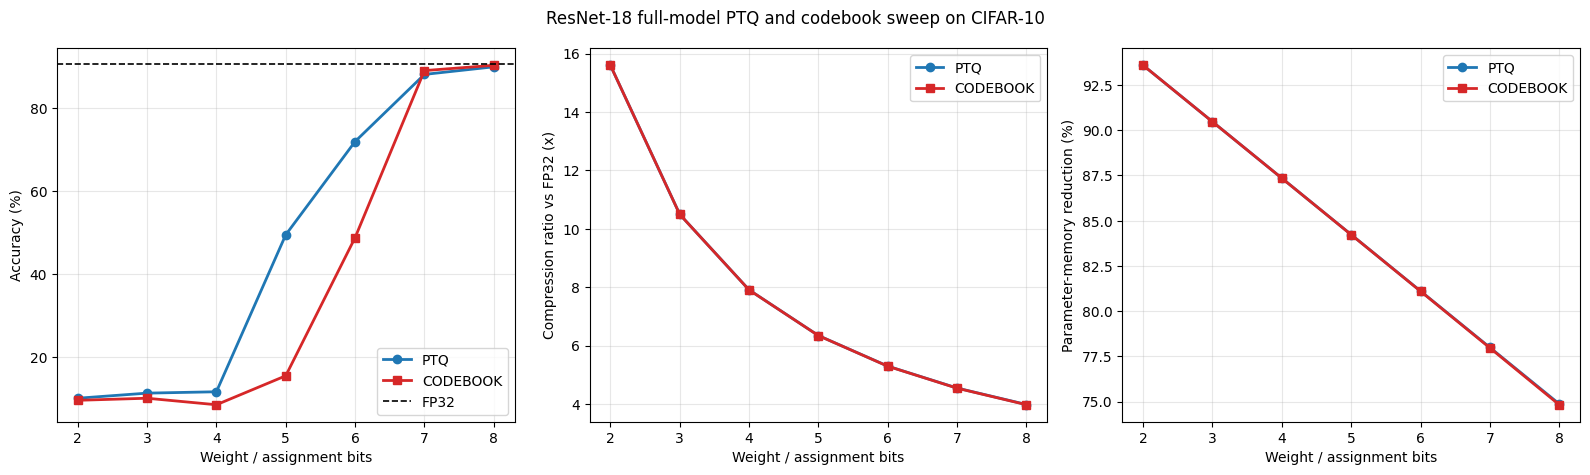

Saved table: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_full_ptq_codebook_bit_sweep/resnet18_ptq_codebook_2_to_8_bit.csv
Saved figure: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_full_ptq_codebook_bit_sweep/resnet18_ptq_codebook_2_to_8_bit.png


In [6]:
comparison = results[[
    'method', 'num_bits', 'correct_predictions', 'test_images', 'accuracy_percent',
    'drop_from_fp32_pp', 'parameter_mib', 'compression_ratio_vs_fp32',
    'memory_reduction_percent',
]].copy()
display(comparison.round({
    'accuracy_percent': 2, 'drop_from_fp32_pp': 2, 'parameter_mib': 2,
    'compression_ratio_vs_fp32': 2, 'memory_reduction_percent': 2,
}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
metric_specs = [
    ('accuracy_percent', 'Accuracy (%)'),
    ('compression_ratio_vs_fp32', 'Compression ratio vs FP32 (x)'),
    ('memory_reduction_percent', 'Parameter-memory reduction (%)'),
]
styles = {'ptq': ('o', '#1f77b4'), 'codebook': ('s', '#d62728')}
for ax, (metric, label) in zip(axes, metric_specs):
    for method in METHODS:
        group = results[results.method.eq(method)].sort_values('num_bits')
        marker, color = styles[method]
        ax.plot(group.num_bits, group[metric], marker=marker, color=color, linewidth=2, label=method.upper())
    if metric == 'accuracy_percent':
        ax.axhline(fp32_accuracy * 100, color='black', linestyle='--', linewidth=1.2, label='FP32')
    ax.set_xlabel('Weight / assignment bits')
    ax.set_ylabel(label)
    ax.set_xticks(BITS)
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.suptitle('ResNet-18 full-model PTQ and codebook sweep on CIFAR-10')
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved table: {RESULT_PATH}')
print(f'Saved figure: {FIGURE_PATH}')


## 6. Save reproducibility metadata


In [7]:
metadata = {
    'model_checkpoint': str(MODEL_PATH),
    'dataset': 'CIFAR-10 complete official test split',
    'test_images': NUM_TEST_IMAGES,
    'bits': list(BITS), 'methods': list(METHODS),
    'eligible_tensor_policy': 'floating tensors with rank >= 2',
    'eligible_tensors': len(candidate_names),
    'ptq': {'per_channel': True, 'symmetric': True},
    'codebook': {
        'vector_dim': 1, 'mode': 'vector', 'codebook_size': '2 ** num_bits',
        'codebook_dtype': 'float32', 'max_kmeans_samples': CODEBOOK_MAX_SAMPLES,
        'kmeans_iterations': CODEBOOK_ITERATIONS,
    },
    'custom_execution': 'reconstructed weights with FP32 Keras activations',
    'fake_quantization_used': False, 'retraining_used': False,
    'random_seed': RANDOM_SEED,
    'tensorflow_version': tf.__version__, 'keras_version': keras.__version__,
}
with (OUTPUT_DIR / 'results.json').open('w') as handle:
    json.dump(metadata, handle, indent=2)
display(pd.Series(metadata, name='value').to_frame())


,value
model_checkpoint,/Users/sahil/Group Studies/Quantization-Group-...
dataset,CIFAR-10 complete official test split
test_images,10000
bits,"[2, 3, 4, 5, 6, 7, 8]"
methods,"[ptq, codebook]"
eligible_tensor_policy,floating tensors with rank >= 2
eligible_tensors,21
ptq,"{'per_channel': True, 'symmetric': True}"
codebook,"{'vector_dim': 1, 'mode': 'vector', 'codebook_..."
custom_execution,reconstructed weights with FP32 Keras activations
